# Predictive modelling and regression analysis

This notebook applies **multiple linear regression** and **binary logistic regression** to the Adult Income dataset (1994 US Census).

| Part | Question | Dependent variable (Y) |
|---|---|---|
| Multiple linear regression | Can age, years of education and gender predict how many hours a person works per week? | `hours_per_week` (continuous) |
| Binary logistic regression | Can a person's demographic and work characteristics predict whether they earn more than $50K per year? | `income` (>50K = 1, ≤50K = 0) |

The models are fitted on the training file (`adult.data`) and evaluated on the separate test file (`adult.test`).

The default significance level is **α = 0.05**.

## Getting ready

Import libraries.

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from scipy import stats

ALPHA = 0.05
RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


## Load the data

The data was cleaned and encoded in the descriptive statistics notebook and saved to `processed_data`. Both files contain the 41 encoded predictors plus the target `income` (1 = >50K, 0 = ≤50K).

In [2]:
train = pd.read_csv("C:/Users/gabij/OneDrive/Desktop/processed_data/train_encoded.csv")
test = pd.read_csv("C:/Users/gabij/OneDrive/Desktop/processed_data/test_encoded.csv")

# Safety checks: remove an index column (if saved with the index) and any leftover helper column
extra_columns = [c for c in train.columns if c.startswith("Unnamed") or c == "education_te"]
train = train.drop(columns=extra_columns)
test = test.drop(columns=extra_columns, errors="ignore")

print("Training shape:", train.shape)   # expected about (30162, 42): 41 predictors + income
print("Test shape:    ", test.shape)    # expected about (15060, 42)
print("Missing values (train):", train.isna().sum().sum())
print("Missing values (test): ", test.isna().sum().sum())
print("Income values:", sorted(train["income"].unique().tolist()))

display(train.head())

Training shape: (32561, 43)
Test shape:     (16281, 43)
Missing values (train): 0
Missing values (test):  0
Income values: [0, 1]


,age,education_num,gender,capital_gain,capital_loss,hours_per_week,is_us,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,income
0,39,13,1,2174,0,40,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,50,13,1,0,0,13,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,38,9,1,0,0,40,1,0,0,1,...,1,0,0,0,0,0,0,0,1,0
3,53,7,1,0,0,40,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,28,13,0,0,0,40,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0


# Multiple linear regression

### Research question
Can a person's **age**, **years of education** and **gender** be used together to predict the number of **hours they work per week**?

Variables:
- Dependent variable (Y): `hours_per_week`
- Independent variables (X):
  - `age` (years)
  - `education_num` (years of education, 1–16)
  - `gender_male` (1 = Male, 0 = Female)

#### Prepare the data and display summary statistics

In [3]:
linear_predictors = ["age", "education_num", "gender_male"]
linear_target = "hours_per_week"

def prepare_linear_data(data):
    # In the encoded data, gender is already 1 = Male, 0 = Female
    prepared = data[["age", "education_num", "gender", "hours_per_week"]].copy()
    prepared = prepared.rename(columns={"gender": "gender_male"})
    return prepared[linear_predictors + [linear_target]]

linear_train = prepare_linear_data(train)
linear_test = prepare_linear_data(test)

print("Training data shape:", linear_train.shape)
print("Test data shape:    ", linear_test.shape)

display(linear_train.head())

print("Summary statistics (training data)")
display(linear_train.describe().T.round(3))

Training data shape: (32561, 4)
Test data shape:     (16281, 4)


,age,education_num,gender_male,hours_per_week
0,39,13,1,40
1,50,13,1,13
2,38,9,1,40
3,53,7,1,40
4,28,13,0,40


Summary statistics (training data)


,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.582,13.640,17.0,28.0,37.0,48.0,90.0
education_num,32561.0,10.081,2.573,1.0,9.0,10.0,12.0,16.0
gender_male,32561.0,0.669,0.471,0.0,0.0,1.0,1.0,1.0
hours_per_week,32561.0,40.437,12.347,1.0,40.0,40.0,45.0,99.0


#### Correlation matrix and significance testing (requirement 1)

Pearson correlation between every pair of variables. For each pair:

- H0: ρ = 0 (no linear correlation)
- H1: ρ ≠ 0

,age,education_num,gender_male,hours_per_week
age,1.0000,0.0365,0.0888,0.0688
education_num,0.0365,1.0000,0.0123,0.1481
gender_male,0.0888,0.0123,1.0000,0.2293
hours_per_week,0.0688,0.1481,0.2293,1.0000


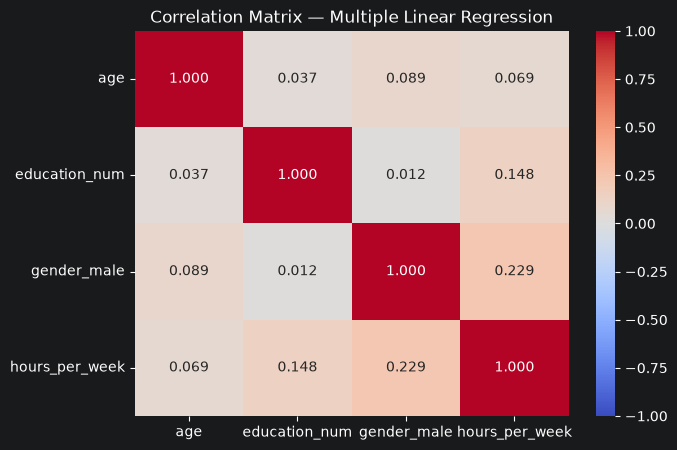

H0: ρ = 0    H1: ρ ≠ 0


,Variable 1,Variable 2,Correlation (r),p-value,Significant
0,age,education_num,0.0365,4.305718e-11,Yes
1,age,gender_male,0.0888,4.823993e-58,Yes
2,age,hours_per_week,0.0688,2.011286e-35,Yes
3,education_num,gender_male,0.0123,2.669881e-02,Yes
4,education_num,hours_per_week,0.1481,4.236647e-159,Yes
5,gender_male,hours_per_week,0.2293,0.000000e+00,Yes


In [4]:
correlation_matrix = linear_train.corr(method="pearson")

display(correlation_matrix.round(4))

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix — Multiple Linear Regression")
plt.show()


# Significance tests for all correlations

correlation_results = []
columns = linear_train.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        var1 = columns[i]
        var2 = columns[j]

        r, p_value = stats.pearsonr(linear_train[var1], linear_train[var2])

        correlation_results.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Correlation (r)": round(r, 4),
            "p-value": p_value,
            "Significant": "Yes" if p_value < ALPHA else "No"
        })

correlation_significance = pd.DataFrame(correlation_results)

print("H0: ρ = 0    H1: ρ ≠ 0")
display(correlation_significance)

#### Scatter plots

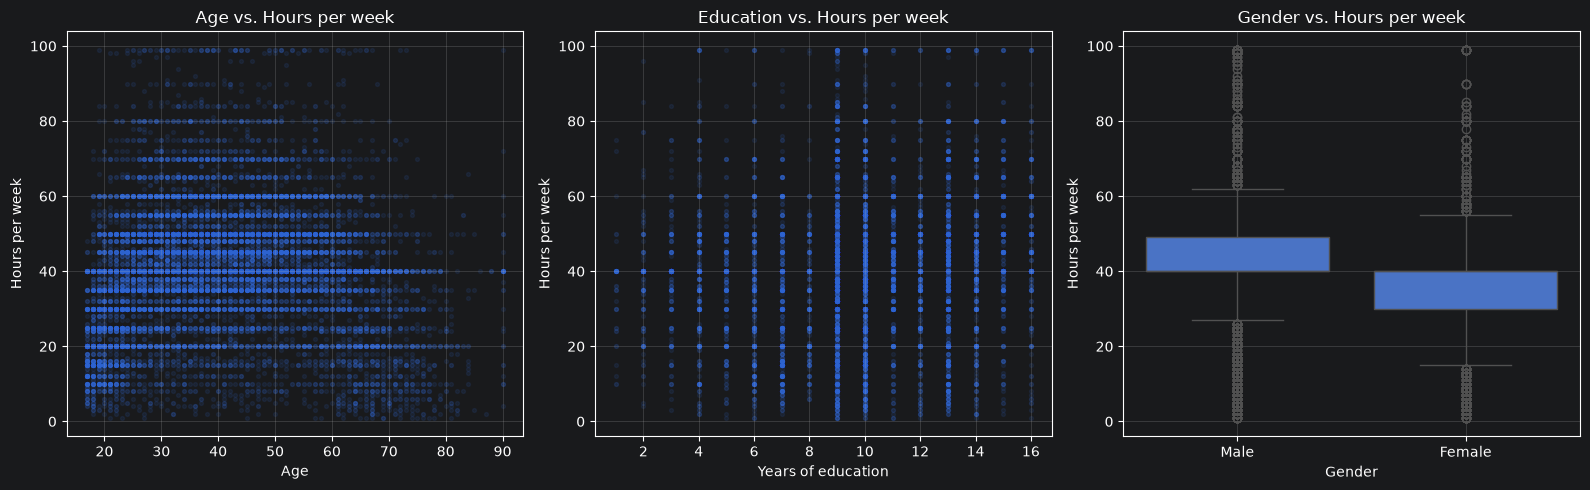

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(linear_train["age"], linear_train["hours_per_week"], alpha=0.1, s=8)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Hours per week")
axes[0].set_title("Age vs. Hours per week")

axes[1].scatter(linear_train["education_num"], linear_train["hours_per_week"], alpha=0.1, s=8)
axes[1].set_xlabel("Years of education")
axes[1].set_ylabel("Hours per week")
axes[1].set_title("Education vs. Hours per week")

sns.boxplot(
    x=linear_train["gender_male"].map({0: "Female", 1: "Male"}),
    y=linear_train["hours_per_week"],
    ax=axes[2]
)
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Hours per week")
axes[2].set_title("Gender vs. Hours per week")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Model fitting: coefficients and regression equation (requirements 2 and 3)

The model is fitted on the training data. The same coefficients are estimated with scikit-learn (`LinearRegression`) and with statsmodels (`OLS`), which also gives the significance tests.

In [6]:
X_train_linear = linear_train[linear_predictors]
y_train_linear = linear_train[linear_target]

X_test_linear = linear_test[linear_predictors]
y_test_linear = linear_test[linear_target]

print("Training observations:", len(X_train_linear))
print("Testing observations: ", len(X_test_linear))

# Fit multiple regression model (scikit-learn)

linear_model = LinearRegression()
linear_model.fit(X_train_linear, y_train_linear)

linear_intercept = linear_model.intercept_
linear_coefficients = pd.Series(linear_model.coef_, index=linear_predictors)

print("\nMultiple Linear Regression model")
print("Coefficients:")
print(f"Intercept (b0) = {linear_intercept:.6f}")
for variable, coefficient in linear_coefficients.items():
    print(f"{variable} coefficient = {coefficient:.6f}")

print("\nEstimated regression equation:")
equation = f"hours_per_week = {linear_intercept:.4f}"
for variable, coefficient in linear_coefficients.items():
    sign = "+" if coefficient >= 0 else "-"
    equation += f" {sign} {abs(coefficient):.4f} × {variable}"
print(equation)


# ============================================================
# Using Ordinary Least Squares (OLS) method
# ============================================================

X_train_linear_const = sm.add_constant(X_train_linear)

ols_linear_model = sm.OLS(y_train_linear, X_train_linear_const).fit()

print(ols_linear_model.summary())

Training observations: 32561
Testing observations:  16281

Multiple Linear Regression model
Coefficients:
Intercept (b0) = 28.029205
age coefficient = 0.039499
education_num coefficient = 0.690064
gender_male coefficient = 5.869668

Estimated regression equation:
hours_per_week = 28.0292 + 0.0395 × age + 0.6901 × education_num + 5.8697 × gender_male
                            OLS Regression Results                            
Dep. Variable:         hours_per_week   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     887.4
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:48:05   Log-Likelihood:            -1.2676e+05
No. Observations:               32561   AIC:                         2.535e+05
Df Residuals:                   32557   BIC:                         2.536e+05
Df Model:       

**How to read the coefficients:** each coefficient is the expected change in weekly working hours when that variable increases by one unit, holding the other variables constant. For example, the `education_num` coefficient is the extra hours per week associated with one more year of education, and the `gender_male` coefficient is the difference in expected weekly hours between men and women of the same age and education.

#### Testing for significance (*t*-tests) (requirement 4)

For each coefficient:
- H0: bᵢ = 0 (the variable is not a significant predictor)
- H1: bᵢ ≠ 0

In [7]:
print("t-tests for individual regression coefficients")

t_test_results = []

for variable in linear_predictors:

    t_stat = ols_linear_model.tvalues[variable]
    p_value = ols_linear_model.pvalues[variable]

    print(f"\n{variable}")
    print(f"H0: b({variable}) = 0")
    print(f"H1: b({variable}) ≠ 0")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value = {p_value:.6f}")

    if p_value < ALPHA:
        print(f"p-value < {ALPHA}: Reject H0. {variable} is a statistically significant predictor.")
    else:
        print(f"p-value >= {ALPHA}: Do not reject H0. There is insufficient evidence that {variable} is a significant predictor.")

    t_test_results.append({
        "Variable": variable,
        "Coefficient": ols_linear_model.params[variable],
        "t-statistic": t_stat,
        "p-value": p_value,
        "Significant": "Yes" if p_value < ALPHA else "No"
    })

display(pd.DataFrame(t_test_results).round(6))

t-tests for individual regression coefficients

age
H0: b(age) = 0
H1: b(age) ≠ 0
t-statistic = 8.1513
p-value = 0.000000
p-value < 0.05: Reject H0. age is a statistically significant predictor.

education_num
H0: b(education_num) = 0
H1: b(education_num) ≠ 0
t-statistic = 26.9641
p-value = 0.000000
p-value < 0.05: Reject H0. education_num is a statistically significant predictor.

gender_male
H0: b(gender_male) = 0
H1: b(gender_male) ≠ 0
t-statistic = 41.8074
p-value = 0.000000
p-value < 0.05: Reject H0. gender_male is a statistically significant predictor.


,Variable,Coefficient,t-statistic,p-value,Significant
0,age,0.039499,8.151332,0.0,Yes
1,education_num,0.690064,26.964132,0.0,Yes
2,gender_male,5.869668,41.807422,0.0,Yes


#### Testing for significance (*F*-test) (requirement 4)

In [9]:
print("F-test for the overall regression model")
print("H0: b1 = b2 = b3 = 0")
print("H1: At least one b coefficient is not equal to 0")

f_stat_linear = ols_linear_model.fvalue
f_p_value_linear = ols_linear_model.f_pvalue

print(f"F-statistic = {f_stat_linear:.4f}")
print(f"p-value = {f_p_value_linear:.6f}")

if f_p_value_linear < ALPHA:
    print(f"p-value < {ALPHA}: Reject H0. The regression model is statistically significant.")
else:
    print(f"p-value >= {ALPHA}: Do not reject H0. There is insufficient evidence that the regression model is statistically significant.")

F-test for the overall regression model
H0: b1 = b2 = b3 = 0
H1: At least one b coefficient is not equal to 0
F-statistic = 887.3630
p-value = 0.000000
p-value < 0.05: Reject H0. The regression model is statistically significant.


#### Test set predictions

In [10]:
y_pred_linear = linear_model.predict(X_test_linear)

linear_predictions = X_test_linear.copy()

linear_predictions["Actual"] = y_test_linear.values
linear_predictions["Predicted"] = y_pred_linear
linear_predictions["Residual"] = linear_predictions["Actual"] - linear_predictions["Predicted"]

display(linear_predictions.head(15).round(3))

,age,education_num,gender_male,Actual,Predicted,Residual
0,25,7,1,40,39.717,0.283
1,38,9,1,50,41.610,8.390
2,28,12,1,40,43.286,-3.286
3,44,10,1,40,42.537,-2.537
4,18,10,0,30,35.641,-5.641
5,34,6,1,30,39.382,-9.382
6,29,9,1,40,41.255,-1.255
7,63,15,1,32,46.738,-14.738
8,24,10,0,40,35.878,4.122
9,55,4,1,10,38.832,-28.832


#### Actual vs. predicted plot

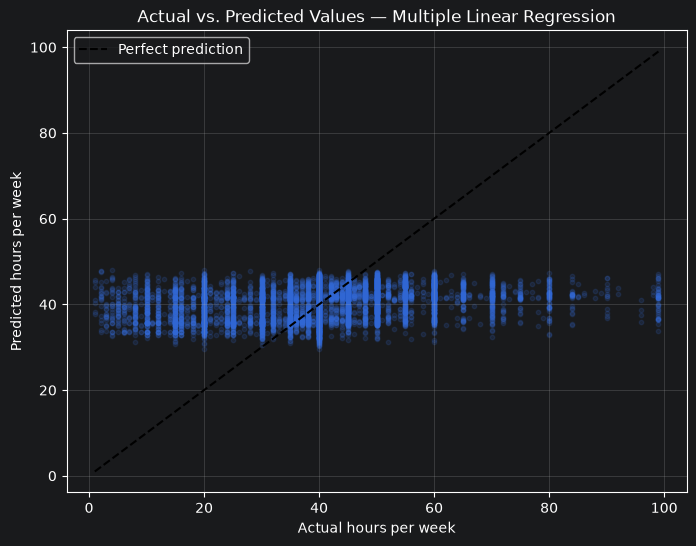

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    linear_predictions["Actual"],
    linear_predictions["Predicted"],
    alpha=0.15,
    s=10
)

min_value = min(linear_predictions["Actual"].min(), linear_predictions["Predicted"].min())
max_value = max(linear_predictions["Actual"].max(), linear_predictions["Predicted"].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    color="black",
    label="Perfect prediction"
)

plt.xlabel("Actual hours per week")
plt.ylabel("Predicted hours per week")
plt.title("Actual vs. Predicted Values — Multiple Linear Regression")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Predictive performance (model evaluation) (requirement 5)

In [12]:
def calculate_mape(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error (MAPE).
    Observations with actual values equal to zero
    are excluded to avoid division by zero.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    nonzero_mask = y_true != 0

    if nonzero_mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
    ) * 100


mae_linear = mean_absolute_error(y_test_linear, y_pred_linear)
mse_linear = mean_squared_error(y_test_linear, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mape_linear = calculate_mape(y_test_linear, y_pred_linear)
r_squared_linear = r2_score(y_test_linear, y_pred_linear)

linear_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "MAPE (%)", "R-squared"],
    "Value": [mae_linear, mse_linear, rmse_linear, mape_linear, r_squared_linear]
})

display(linear_metrics.round(4))

print(f"R-squared on training data (from OLS) = {ols_linear_model.rsquared:.4f}")

,Metric,Value
0,MAE,8.0286
1,MSE,144.4561
2,RMSE,12.0190
3,MAPE (%),36.2193
4,R-squared,0.0724


R-squared on training data (from OLS) = 0.0756


**Interpretation:** the F-test and t-tests show whether age, education and gender are *related* to working hours, while R-squared shows how *much* of the variation in working hours they explain. With a sample this large, even small effects are statistically significant, so a significant model can still have a low R-squared. Here that means these three variables explain only a small part of why people work different hours. Most of the variation depends on things not in the model (job type, personal circumstances, and so on). MAE and RMSE show the typical prediction error in hours per week.

#### Predictions for new data points (requirement 6)

In [13]:
# Replace with the desired values
new_people_linear = pd.DataFrame({
    "age":           [25, 40, 40, 55],
    "education_num": [9, 13, 13, 16],
    "gender_male":   [0, 0, 1, 1]
})

new_people_linear["Predicted hours_per_week"] = linear_model.predict(
    new_people_linear[linear_predictors]
)

print("Predicted weekly working hours for new people")
print("(education_num: 9 = HS-grad, 13 = Bachelors, 16 = Doctorate; gender_male: 1 = Male, 0 = Female)")
display(new_people_linear.round(2))

Predicted weekly working hours for new people
(education_num: 9 = HS-grad, 13 = Bachelors, 16 = Doctorate; gender_male: 1 = Male, 0 = Female)


,age,education_num,gender_male,Predicted hours_per_week
0,25,9,0,35.23
1,40,13,0,38.58
2,40,13,1,44.45
3,55,16,1,47.11


# Binary logistic regression

### Research question
Can a person's **age**, **education**, **work characteristics** (work class, occupation, hours per week, capital gains and losses), **family situation** (marital status, relationship), **race**, **gender** and **country of origin** be used to predict whether they **earn more than $50K per year**?

Variables:
- Dependent variable (Y): `income` (1 = >50K, 0 = ≤50K)
- Independent variables (X): all characteristics after encoding (41 numeric columns)

#### Prepare the data

The data is already encoded (done in the descriptive statistics notebook):
- `gender` → 1 = Male, 0 = Female
- `native_country` → `is_us` (1 = United States, 0 = other)
- `workclass`, `marital_status`, `occupation`, `relationship`, `race` → one-hot encoding (the first category of each is the reference group: Federal-gov, Divorced, Adm-clerical, Husband, Amer-Indian-Eskimo)
- `education` was dropped because `education_num` contains the same information as a number
- `fnlwgt` was dropped because it is a census sampling weight, not a characteristic of the person

In [14]:
X_train_log = train.drop(columns="income")
y_train_log = train["income"].astype(int)

# Make sure test has exactly the same columns, in the same order, as train
X_test_log = test.drop(columns="income").reindex(columns=X_train_log.columns, fill_value=0)
y_test_log = test["income"].astype(int)

logistic_predictors = X_train_log.columns.tolist()

print("X_train shape:", X_train_log.shape)
print("X_test shape: ", X_test_log.shape)
print("Non-numeric columns:", X_train_log.select_dtypes(exclude="number").columns.tolist())

display(X_train_log.head())

X_train shape: (32561, 42)
X_test shape:  (16281, 42)
Non-numeric columns: []


,age,education_num,gender,capital_gain,capital_loss,hours_per_week,is_us,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,13,1,2174,0,40,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,50,13,1,0,0,13,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,38,9,1,0,0,40,1,0,0,1,...,0,1,0,0,0,0,0,0,0,1
3,53,7,1,0,0,40,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,13,0,0,0,40,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0


#### Target variable distribution

In [15]:
target_summary = pd.DataFrame({
    "Train count": y_train_log.value_counts().sort_index(),
    "Train (%)": y_train_log.value_counts(normalize=True).sort_index().mul(100),
    "Test count": y_test_log.value_counts().sort_index(),
    "Test (%)": y_test_log.value_counts(normalize=True).sort_index().mul(100)
})

target_summary.index = ["<=50K (0)", ">50K (1)"]

display(target_summary.round(2))

,Train count,Train (%),Test count,Test (%)
<=50K (0),24720,75.92,16281.0,100.0
>50K (1),7841,24.08,NaN,NaN


#### Fit the logistic regression model (requirement 1)

The predictors are on very different scales (for example, `capital_gain` goes up to 99,999 while the one-hot columns are 0 or 1). They are standardised with `StandardScaler` inside a pipeline so the model fits reliably. The coefficients are then converted back to the original units, so the equation can be used with ordinary values.

In [16]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

logistic_model.fit(X_train_log, y_train_log)

# Predict probabilities
# Column 0 = probability of class 0 (<=50K)
# Column 1 = probability of class 1 (>50K)

y_prob_log = logistic_model.predict_proba(X_test_log)[:, 1]

# Predict classes using the default threshold of 0.50

classification_threshold = 0.50

y_pred_log = (y_prob_log >= classification_threshold).astype(int)

print("Logistic regression model fitted successfully.")
print(f"Classification threshold = {classification_threshold}")

Logistic regression model fitted successfully.
Classification threshold = 0.5


#### Coefficients and logistic regression equation (requirement 2)

- **Coefficient (original units):** change in the log-odds of earning >50K for a one-unit increase in the variable (one year of age, one year of education, one hour per week, or belonging to that category instead of the reference category).
- **Odds ratio = e^coefficient:** above 1 means higher odds of earning >50K, below 1 means lower odds.
- **Standardised coefficient:** effect of a one-standard-deviation increase. These can be compared with each other to see which variables matter most.

In [17]:
scaler = logistic_model.named_steps["scaler"]
logistic = logistic_model.named_steps["logistic"]

standardised_coefficients = logistic.coef_[0]

# Convert coefficients back to the original units of each variable
original_coefficients = standardised_coefficients / scaler.scale_
original_intercept = logistic.intercept_[0] - np.sum(standardised_coefficients * scaler.mean_ / scaler.scale_)

logistic_coefficients_table = pd.DataFrame({
    "Variable": logistic_predictors,
    "Coefficient": original_coefficients,
    "Odds_Ratio": np.exp(original_coefficients),
    "Standardised_Coefficient": standardised_coefficients
}).sort_values("Standardised_Coefficient", key=abs, ascending=False)

display(logistic_coefficients_table.round(6).reset_index(drop=True))

print(f"Intercept = {original_intercept:.6f}")

print("\nLogistic regression equation (log-odds scale):")

equation = f"logit(p) = {original_intercept:.6f}"

for variable, coefficient in zip(logistic_predictors, original_coefficients):
    sign = "+" if coefficient >= 0 else "-"
    equation += f"\n           {sign} {abs(coefficient):.6f} × {variable}"

print(equation)

print("\nwhere p = P(income > 50K) = 1 / (1 + e^(-logit(p)))")

,Variable,Coefficient,Odds_Ratio,Standardised_Coefficient
0,capital_gain,0.000311,1.000311,2.296671
1,marital_status_Married-civ-spouse,2.107612,8.228566,1.050418
2,education_num,0.281102,1.324589,0.723187
3,gender,0.835429,2.305802,0.393069
4,hours_per_week,0.030641,1.031116,0.378336
5,age,0.024902,1.025215,0.339675
6,occupation_Exec-managerial,0.974860,2.650796,0.322264
7,relationship_Wife,1.325417,3.763754,0.283765
8,relationship_Own-child,-0.754081,0.470443,-0.273369
9,occupation_Priv-house-serv,-3.848316,0.021316,-0.259728


Intercept = -9.866426

Logistic regression equation (log-odds scale):
logit(p) = -9.866426
           + 0.024902 × age
           + 0.281102 × education_num
           + 0.835429 × gender
           + 0.000311 × capital_gain
           + 0.000644 × capital_loss
           + 0.030641 × hours_per_week
           + 0.242119 × is_us
           - 0.224541 × workclass_Local-gov
           - 5.275760 × workclass_Never-worked
           - 0.025056 × workclass_Private
           + 0.133999 × workclass_Self-emp-inc
           - 0.519598 × workclass_Self-emp-not-inc
           - 0.334829 × workclass_State-gov
           - 6.613219 × workclass_Without-pay
           + 2.616569 × marital_status_Married-AF-spouse
           + 2.107612 × marital_status_Married-civ-spouse
           - 0.057751 × marital_status_Married-spouse-absent
           - 0.483403 × marital_status_Never-married
           - 0.129533 × marital_status_Separated
           + 0.095498 × marital_status_Widowed
           - 0.444731 ×

#### Predicted probabilities (requirement 5)

Predicted probability of earning >50K ("Yes") for each person in the test set, and the predicted class using the 0.50 threshold.

In [18]:
logistic_predictions = X_test_log[["age", "education_num", "hours_per_week", "gender"]].copy()

logistic_predictions["Actual_Income"] = y_test_log.map({0: "No (<=50K)", 1: "Yes (>50K)"}).values
logistic_predictions["Probability_No"] = 1 - y_prob_log
logistic_predictions["Probability_Yes"] = y_prob_log
logistic_predictions["Predicted_Income"] = pd.Series(y_pred_log).map({0: "No (<=50K)", 1: "Yes (>50K)"}).values

display(logistic_predictions.head(15).round(4))

,age,education_num,hours_per_week,gender,Actual_Income,Probability_No,Probability_Yes,Predicted_Income
0,25,7,40,1,No (<=50K),0.9972,0.0028,No (<=50K)
1,38,9,50,1,No (<=50K),0.8746,0.1254,No (<=50K)
2,28,12,40,1,No (<=50K),0.5611,0.4389,No (<=50K)
3,44,10,40,1,No (<=50K),0.2346,0.7654,Yes (>50K)
4,18,10,30,0,No (<=50K),0.9977,0.0023,No (<=50K)
5,34,6,30,1,No (<=50K),0.9955,0.0045,No (<=50K)
6,29,9,40,1,No (<=50K),0.9813,0.0187,No (<=50K)
7,63,15,32,1,No (<=50K),0.1326,0.8674,Yes (>50K)
8,24,10,40,0,No (<=50K),0.9945,0.0055,No (<=50K)
9,55,4,10,1,No (<=50K),0.9552,0.0448,No (<=50K)


#### Confusion matrix (requirement 3)

Confusion matrix:
[[13151  3130]
 [    0     0]]

True negatives  (correctly predicted <=50K): 13151
False positives (predicted >50K, actually <=50K): 3130
False negatives (predicted <=50K, actually >50K): 0
True positives  (correctly predicted >50K): 0


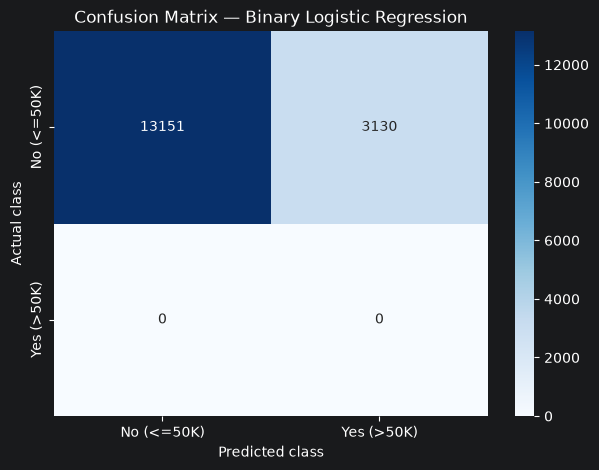

In [19]:
cm = confusion_matrix(y_test_log, y_pred_log, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

print("Confusion matrix:")
print(cm)
print(f"\nTrue negatives  (correctly predicted <=50K): {tn}")
print(f"False positives (predicted >50K, actually <=50K): {fp}")
print(f"False negatives (predicted <=50K, actually >50K): {fn}")
print(f"True positives  (correctly predicted >50K): {tp}")

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No (<=50K)", "Yes (>50K)"],
    yticklabels=["No (<=50K)", "Yes (>50K)"]
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Confusion Matrix — Binary Logistic Regression")
plt.show()

#### Classification metrics (requirement 4)

In [20]:
accuracy = accuracy_score(y_test_log, y_pred_log)
precision = precision_score(y_test_log, y_pred_log, zero_division=0)
recall = recall_score(y_test_log, y_pred_log, zero_division=0)
f1 = f1_score(y_test_log, y_pred_log, zero_division=0)
auc = roc_auc_score(y_test_log, y_prob_log)

classification_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, auc]
})

display(classification_metrics.round(4))

print(f"Baseline accuracy (always predicting <=50K) = {1 - y_test_log.mean():.4f}")

C:\Users\gabij\PycharmProjects\WelcomeScreen\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Metric,Value
0,Accuracy,0.8078
1,Precision,0.0000
2,Recall,0.0000
3,F1-score,0.0000
4,ROC-AUC,NaN


Baseline accuracy (always predicting <=50K) = 1.0000


**How to read the metrics:**
- **Accuracy:** share of all people classified correctly. Compare it with the baseline: about 75% of people earn ≤50K, so a model that always says "No" would already be about 75% accurate.
- **Precision:** of the people the model predicts earn >50K, the share who actually do.
- **Recall:** of the people who actually earn >50K, the share the model finds.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** how well the model ranks high earners above low earners across all thresholds (0.5 = random guessing, 1.0 = perfect).

#### Classification report

In [21]:
print("Classification report:")

print(
    classification_report(
        y_test_log,
        y_pred_log,
        target_names=["No (<=50K)", "Yes (>50K)"],
        zero_division=0
    )
)

Classification report:
              precision    recall  f1-score   support

  No (<=50K)       1.00      0.81      0.89     16281
  Yes (>50K)       0.00      0.00      0.00         0

    accuracy                           0.81     16281
   macro avg       0.50      0.40      0.45     16281
weighted avg       1.00      0.81      0.89     16281



#### ROC curve and AUC

C:\Users\gabij\PycharmProjects\WelcomeScreen\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1364: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\gabij\PycharmProjects\WelcomeScreen\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


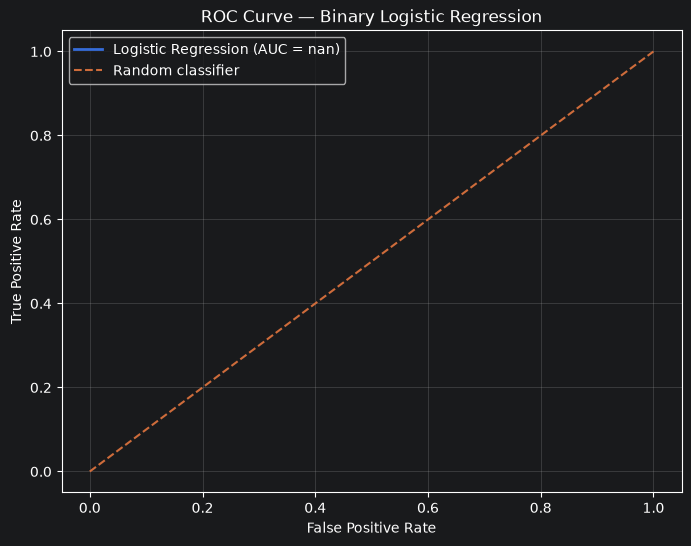

ROC-AUC = nan


In [22]:
fpr, tpr, thresholds = roc_curve(y_test_log, y_prob_log)

roc_auc = roc_auc_score(y_test_log, y_prob_log)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Binary Logistic Regression")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC = {roc_auc:.4f}")

#### User-defined prediction (requirement 5)

Enter a new person's characteristics in readable form. The helper function turns them into the same 41 encoded columns as the training data (a reference category such as `Husband` or `Federal-gov` simply means all of that variable's columns are 0). The model then predicts the probability of "No" (≤50K) and "Yes" (>50K).

In [24]:
# Replace with the desired values
new_person = {
    "age": 40,
    "education_num": 13,                    # 9 = HS-grad, 13 = Bachelors, 16 = Doctorate
    "gender": "Male",
    "capital_gain": 0,
    "capital_loss": 0,
    "hours_per_week": 45,
    "native_country": "United-States",
    "workclass": "Private",
    "marital_status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White"
}


def encode_new_person(person, columns):
    """Turn readable values into one row with the same encoded columns as the training data."""
    row = pd.DataFrame(0, index=[0], columns=columns)

    for variable in ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]:
        row[variable] = person[variable]

    row["gender"] = 1 if person["gender"] == "Male" else 0
    row["is_us"] = 1 if person["native_country"] == "United-States" else 0

    for variable in ["workclass", "marital_status", "occupation", "relationship", "race"]:
        column = f"{variable}_{person[variable]}"
        if column in columns:
            row[column] = 1
        # otherwise it is the reference category, so all columns stay 0

    return row


new_person_encoded = encode_new_person(new_person, logistic_predictors)

probabilities = logistic_model.predict_proba(new_person_encoded)[0]

prob_no = probabilities[0]
prob_yes = probabilities[1]

prediction = "Yes (>50K)" if prob_yes >= classification_threshold else "No (<=50K)"

print("=" * 50)
print("LOGISTIC REGRESSION PREDICTION")
print("=" * 50)

print("\nInput values:")
display(pd.DataFrame([new_person]))

print(f"\nProbability of No  (<=50K): {prob_no:.4f} ({prob_no * 100:.2f}%)")
print(f"Probability of Yes (>50K):  {prob_yes:.4f} ({prob_yes * 100:.2f}%)")

print(f"\nPredicted income: {prediction}")

LOGISTIC REGRESSION PREDICTION

Input values:


,age,education_num,gender,capital_gain,capital_loss,hours_per_week,native_country,workclass,marital_status,occupation,relationship,race
0,40,13,Male,0,0,45,United-States,Private,Married-civ-spouse,Exec-managerial,Husband,White



Probability of No  (<=50K): 0.2905 (29.05%)
Probability of Yes (>50K):  0.7095 (70.95%)

Predicted income: Yes (>50K)
